# Local Room Designer

This notebook uses local files from `data/` only.

- `room.jpg` is the room background.
- Every other `.jpg` file in `data/` is treated as a furniture or decor asset.
- Use the interactive controls below to place items, resize them, rotate them, flip them, and export the final composition.

The design goal is simplicity: you choose the furniture and place it yourself.

In [ ]:
from io import BytesIO
from pathlib import Path

from IPython.display import HTML, display
from PIL import Image, ImageOps

RESAMPLING = getattr(Image, "Resampling", Image)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
ROOM_IMAGE_PATH = DATA_DIR / "room.jpg"
EXPORT_PATH = DATA_DIR / "designed_room.png"


def asset_label(path: Path) -> str:
    label = path.stem.replace("_", " ").replace("image", "")
    return " ".join(word.capitalize() for word in label.split())


def sample_background(image: Image.Image) -> tuple[int, int, int]:
    rgb = image.convert("RGB")
    corners = [
        rgb.getpixel((0, 0)),
        rgb.getpixel((rgb.width - 1, 0)),
        rgb.getpixel((0, rgb.height - 1)),
        rgb.getpixel((rgb.width - 1, rgb.height - 1)),
    ]
    return tuple(sum(pixel[i] for pixel in corners) // len(corners) for i in range(3))


def remove_simple_background(image: Image.Image, tolerance: int = 45) -> Image.Image:
    rgba = ImageOps.exif_transpose(image).convert("RGBA")
    background = sample_background(rgba)
    pixels = []
    for red, green, blue, alpha in rgba.getdata():
        near_background = (
            abs(red - background[0]) <= tolerance
            and abs(green - background[1]) <= tolerance
            and abs(blue - background[2]) <= tolerance
        )
        very_light = red >= 245 and green >= 245 and blue >= 245
        pixels.append((red, green, blue, 0 if near_background or very_light else alpha))
    rgba.putdata(pixels)
    bbox = rgba.getbbox()
    return rgba.crop(bbox) if bbox else rgba


ASSET_PATHS = {
    asset_label(path): path
    for path in sorted(DATA_DIR.glob("*.jpg"))
    if path.name.lower() != "room.jpg"
}

if not ROOM_IMAGE_PATH.exists():
    raise FileNotFoundError(f"Room image not found: {ROOM_IMAGE_PATH}")
if not ASSET_PATHS:
    raise FileNotFoundError(f"No furniture images found in {DATA_DIR}")

ROOM_IMAGE = Image.open(ROOM_IMAGE_PATH).convert("RGBA")
ROOM_WIDTH, ROOM_HEIGHT = ROOM_IMAGE.size
ASSET_IMAGES = {label: remove_simple_background(Image.open(path)) for label, path in ASSET_PATHS.items()}


display(
    HTML(
        f"<b>Room:</b> {ROOM_IMAGE_PATH.name} &nbsp; "
        f"<b>Assets:</b> {', '.join(ASSET_PATHS)} &nbsp; "
        f"<b>Canvas:</b> {ROOM_WIDTH} x {ROOM_HEIGHT}"
    )
)


/var/folders/q3/51ssvzc55g53tl0lb2jl9j240000gn/T/ipykernel_26138/1767422779.py:35: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  for red, green, blue, alpha in rgba.getdata():


## Mouse Drag Designer (2D)

Use this panel when you want direct mouse interaction:

- Choose an asset and click **Add**.
- Drag any object with the mouse.
- Use the **Rot X** / **Rot Y** sliders to tilt the object on X and Y axes.
- Use the **↺ Z** / **↻ Z** buttons or mouse wheel to spin on the Z axis.
- Use the **Size** slider to resize selected object.
- Press **Delete Selected** to remove it.


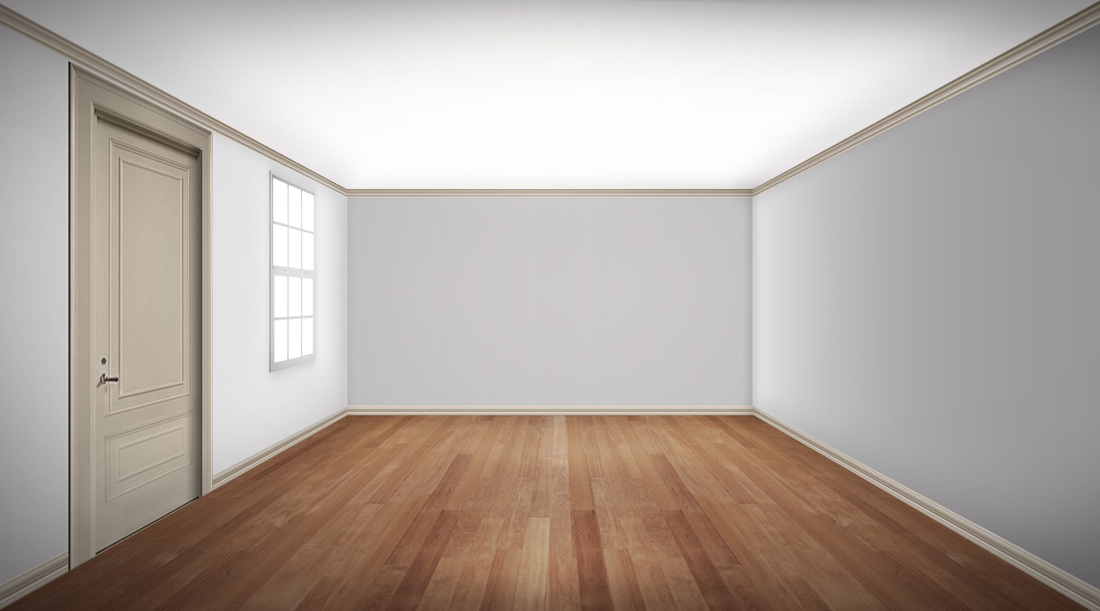
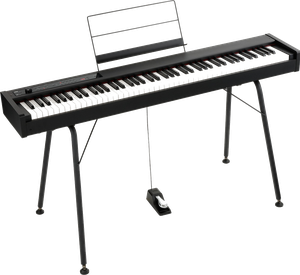
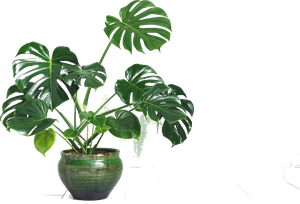
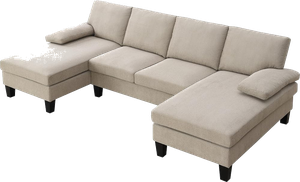
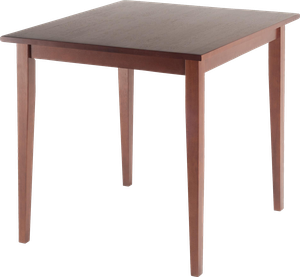
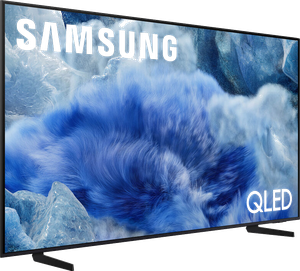

In [3]:
import base64



import json



import uuid











def pil_to_data_url(image: Image.Image) -> str:



    buffer = BytesIO()



    image.save(buffer, format="PNG")



    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")



    return f"data:image/png;base64,{encoded}"











room_preview = ROOM_IMAGE.copy()



room_preview.thumbnail((1100, 650), RESAMPLING.LANCZOS)



room_data_url = pil_to_data_url(room_preview)







asset_urls = {}



for name, image in ASSET_IMAGES.items():



    asset = image.copy()



    target_width = min(300, max(120, asset.width))



    target_height = max(80, int(asset.height * (target_width / asset.width)))



    asset = asset.resize((target_width, target_height), RESAMPLING.LANCZOS)



    asset_urls[name] = pil_to_data_url(asset)







payload = {



    "room": room_data_url,



    "assets": asset_urls,



    "width": room_preview.width,



    "height": room_preview.height,



}



container_id = f"drag-room-{uuid.uuid4().hex}"



payload_json = json.dumps(payload)







html = f"""



<div id=\"{container_id}\"></div>



<script>



(() => {{



  const root = document.getElementById("{container_id}");



  const DATA = {payload_json};







  root.innerHTML = `



    <style>



      .drag-wrap {{ font-family: sans-serif; }}



      .drag-toolbar {{ display: flex; gap: 10px; align-items: center; margin: 0 0 10px 0; flex-wrap: wrap; }}



      .drag-stage {{



        position: relative;



        width: ${{DATA.width}}px;



        height: ${{DATA.height}}px;



        background-image: url('${{DATA.room}}');



        background-size: cover;



        background-position: center;



        border: 1px solid #bbb;



        box-shadow: 0 3px 12px rgba(0,0,0,0.12);



        overflow: hidden;



        touch-action: none;



      }}



      .drag-item {{



        position: absolute;



        left: 50%;



        top: 50%;



        width: 220px;



        transform: translate(-50%, -50%);



        cursor: grab;



        user-select: none;



        border: 2px solid transparent;



        transform-origin: center bottom;



      }}



      .drag-item.selected {{ border-color: #0a84ff; }}



      .drag-status {{ margin-top: 8px; color: #444; font-size: 13px; }}



    </style>



    <div class=\"drag-wrap\">



      <div class=\"drag-toolbar\">



        <label>Asset</label>



        <select id=\"assetSelect\"></select>



        <button id=\"addBtn\">Add</button>



        <button id=\"delBtn\">Delete Selected</button>



        <label>Size</label>



        <input id=\"sizeRange\" type=\"range\" min=\"60\" max=\"500\" value=\"220\" step=\"5\" />



        <label>Rot X</label>



        <input id=\"rotXRange\" type=\"range\" min=\"-180\" max=\"180\" value=\"0\" step=\"5\" style=\"width:90px\" />



        <label>Yaw (Y)</label>



        <input id=\"rotYRange\" type=\"range\" min=\"-180\" max=\"180\" value=\"0\" step=\"1\" style=\"width:120px\" />

        <label>Rot Z</label>

        <input id=\"rotZRange\" type=\"range\" min=\"-180\" max=\"180\" value=\"0\" step=\"1\" style=\"width:120px\" />



        <button id=\"rotLeftBtn\">&#8634; Z</button>



        <button id=\"rotRightBtn\">&#8635; Z</button>



        <button id=\"flipBtn\">&#8646; Flip</button>



      </div>



      <div id=\"stage\" class=\"drag-stage\"></div>



      <div id=\"status\" class=\"drag-status\">Tip: Drag to move. Wheel = Z spin. Use Yaw (Y) slider for free vertical-axis rotation.</div>



    </div>



  `;







  const assetSelect = root.querySelector('#assetSelect');



  const addBtn = root.querySelector('#addBtn');



  const delBtn = root.querySelector('#delBtn');



  const sizeRange = root.querySelector('#sizeRange');



  const rotXRange = root.querySelector('#rotXRange');



  const rotYRange = root.querySelector('#rotYRange');

  const rotZRange = root.querySelector('#rotZRange');



  const rotLeftBtn = root.querySelector('#rotLeftBtn');



  const rotRightBtn = root.querySelector('#rotRightBtn');



  const flipBtn = root.querySelector('#flipBtn');



  const stage = root.querySelector('#stage');



  const status = root.querySelector('#status');







  const names = Object.keys(DATA.assets);



  names.forEach(name => {{



    const option = document.createElement('option');



    option.value = name;



    option.textContent = name;



    assetSelect.appendChild(option);



  }});







  let selected = null;







  function clamp(v, lo, hi) {{



    return Math.max(lo, Math.min(hi, v));



  }}







  function applyItemState(item) {{



    const x = Number(item.dataset.x);



    const y = Number(item.dataset.y);



    const w = Number(item.dataset.w);



    const rot = Number(item.dataset.rot);



    const flipped = item.dataset.flipped === 'true';



    item.style.left = `${{x}}px`;



    item.style.top = `${{y}}px`;



    item.style.width = `${{w}}px`;



    const rotX = Number(item.dataset.rotx || 0);



    const rotY = Number(item.dataset.roty || 0);



    const estimatedHeight = w * 1.2;



    const yShift = (Math.cos(rotX * Math.PI / 180) - 1) * estimatedHeight / 4;



    item.style.transform = `perspective(1400px) translate(-50%, calc(-50% + ${{yShift}}px)) rotateX(${{rotX * 0.6}}deg) rotateY(${{rotY}}deg) rotateZ(${{rot}}deg) scaleX(${{flipped ? -1 : 1}})`;



  }}







  function setSelected(item) {{



    if (selected) selected.classList.remove('selected');



    selected = item;



    if (selected) {{



      selected.classList.add('selected');



      sizeRange.value = String(Math.round(Number(selected.dataset.w)));



      rotXRange.value = String(Math.round(Number(selected.dataset.rotx || 0)));



      rotYRange.value = String(Math.round(Number(selected.dataset.roty || 0)));

      rotZRange.value = String(Math.round(Number(selected.dataset.rot || 0)));



      status.textContent = `Selected: ${{selected.dataset.name}} | rotX=${{Math.round(Number(selected.dataset.rotx||0))}}, rotY=${{Math.round(Number(selected.dataset.roty||0))}}, rotZ=${{Math.round(Number(selected.dataset.rot))}}`;



    }} else {{



      status.textContent = 'Tip: Drag to move. Wheel = Z spin. Use Yaw (Y) slider for free vertical-axis rotation.';



    }}



  }}







  function addItem(name) {{



    const img = document.createElement('img');



    img.className = 'drag-item';



    img.src = DATA.assets[name];



    img.draggable = false;



    img.dataset.name = name;



    img.dataset.x = String(Math.round(DATA.width * 0.5));



    img.dataset.y = String(Math.round(DATA.height * 0.7));



    img.dataset.w = sizeRange.value;



    img.dataset.rot = '0';



    img.dataset.rotx = '0';



    img.dataset.roty = '0';



    img.dataset.flipped = 'false';







    let dragging = false;



    let dx = 0;



    let dy = 0;







    img.addEventListener('pointerdown', (event) => {{



      event.preventDefault();



      setSelected(img);



      dragging = true;



      img.setPointerCapture(event.pointerId);



      const rect = stage.getBoundingClientRect();



      dx = event.clientX - rect.left - Number(img.dataset.x);



      dy = event.clientY - rect.top - Number(img.dataset.y);



      img.style.cursor = 'grabbing';



    }});







    img.addEventListener('pointermove', (event) => {{



      if (!dragging) return;



      const rect = stage.getBoundingClientRect();



      const nx = clamp(event.clientX - rect.left - dx, 0, rect.width);



      const ny = clamp(event.clientY - rect.top - dy, 0, rect.height);



      img.dataset.x = String(nx);



      img.dataset.y = String(ny);



      applyItemState(img);



      status.textContent = `Moving: ${{img.dataset.name}} | x=${{Math.round(nx)}}, y=${{Math.round(ny)}}, rot=${{Math.round(Number(img.dataset.rot))}}`;



    }});







    img.addEventListener('pointerup', () => {{



      dragging = false;



      img.style.cursor = 'grab';



    }});







    img.addEventListener('click', (event) => {{



      event.stopPropagation();



      setSelected(img);



    }});







    img.addEventListener('wheel', (event) => {{



      if (selected !== img) return;



      event.preventDefault();



      const current = Number(img.dataset.rot);



      const next = current + (event.deltaY > 0 ? 5 : -5);



      img.dataset.rot = String(next);



      applyItemState(img);



      rotZRange.value = String(Math.round(next));

      status.textContent = `Rotated: ${{img.dataset.name}} | rot=${{Math.round(next)}}`;



    }}, {{ passive: false }});







    stage.appendChild(img);



    applyItemState(img);



    setSelected(img);



  }}







  addBtn.addEventListener('click', () => addItem(assetSelect.value));



  delBtn.addEventListener('click', () => {{



    if (!selected) return;



    selected.remove();



    setSelected(null);



  }});







  sizeRange.addEventListener('input', () => {{



    if (!selected) return;



    selected.dataset.w = sizeRange.value;



    applyItemState(selected);



  }});







  rotXRange.addEventListener('input', () => {{



    if (!selected) return;



    selected.dataset.rotx = rotXRange.value;



    applyItemState(selected);



    status.textContent = `RotX: ${{selected.dataset.name}} | rotX=${{rotXRange.value}}, rotY=${{selected.dataset.roty||0}}, rotZ=${{Math.round(Number(selected.dataset.rot))}}`;



  }});







  rotYRange.addEventListener('input', () => {{



    if (!selected) return;



    selected.dataset.roty = rotYRange.value;



    applyItemState(selected);



    status.textContent = `RotY: ${{selected.dataset.name}} | rotX=${{selected.dataset.rotx||0}}, rotY=${{rotYRange.value}}, rotZ=${{Math.round(Number(selected.dataset.rot))}}`;



  }});







  rotZRange.addEventListener('input', () => {{

    if (!selected) return;

    selected.dataset.rot = rotZRange.value;

    applyItemState(selected);

    status.textContent = `RotZ: ${{selected.dataset.name}} | rotX=${{selected.dataset.rotx||0}}, rotY=${{selected.dataset.roty||0}}, rotZ=${{rotZRange.value}}`;

  }});



  rotLeftBtn.addEventListener('click', () => {{



    if (!selected) return;



    const next = Number(selected.dataset.rot) - 15;



    selected.dataset.rot = String(next);



    applyItemState(selected);



    rotZRange.value = String(Math.round(next));

    status.textContent = `Rotated: ${{selected.dataset.name}} | rot=${{Math.round(next)}}`;



  }});







  rotRightBtn.addEventListener('click', () => {{



    if (!selected) return;



    const next = Number(selected.dataset.rot) + 15;



    selected.dataset.rot = String(next);



    applyItemState(selected);



    rotZRange.value = String(Math.round(next));

    status.textContent = `Rotated: ${{selected.dataset.name}} | rot=${{Math.round(next)}}`;



  }});







  flipBtn.addEventListener('click', () => {{



    if (!selected) return;



    selected.dataset.flipped = selected.dataset.flipped === 'true' ? 'false' : 'true';



    applyItemState(selected);



    status.textContent = `Flipped: ${{selected.dataset.name}} | flip=${{selected.dataset.flipped}}`;



  }});







  stage.addEventListener('click', () => setSelected(null));







  if (names.length > 0) addItem(names[0]);



}})();



</script>



"""







display(HTML(html))